In [1]:
import matplotlib
import numpy as np

from matplotlib import pyplot as plt
from model_tools import ModelAnalysis, RasterAnalysis, make_image

#Set plotting look and feel

host_color = matplotlib.colors.to_rgb('#0000a2')
path_color = matplotlib.colors.to_rgb('#bc272d')
coevol_color = matplotlib.colors.to_rgb('#e9c716')

s_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", host_color])
i_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", path_color])

plot_label_size = 8
axis_title_size = 12
axis_label_size = 6
tick_label_size = 6

matplotlib.rcParams['axes.titlesize'] = axis_title_size
matplotlib.rcParams['axes.labelsize'] = axis_label_size
matplotlib.rcParams['xtick.labelsize'] = tick_label_size
matplotlib.rcParams['ytick.labelsize'] = tick_label_size

matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{xfrac}'

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'Helvetica'
})

# Figure S1: Nonequal Rates of Evolution #

In [2]:
default_path = 'data/default_init_50_coevol.p'
fast_evo_path = 'data/fast_pathogen_evolution_init_50_coevol.p'

default_raster = RasterAnalysis(default_path, arg_x='m', arg_y='z')
fast_evo_raster = RasterAnalysis(fast_evo_path, arg_x='m', arg_y='z')

/tmp/ipykernel_301194/4196778911.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])


Text(-0.1, 1.1, 'D')

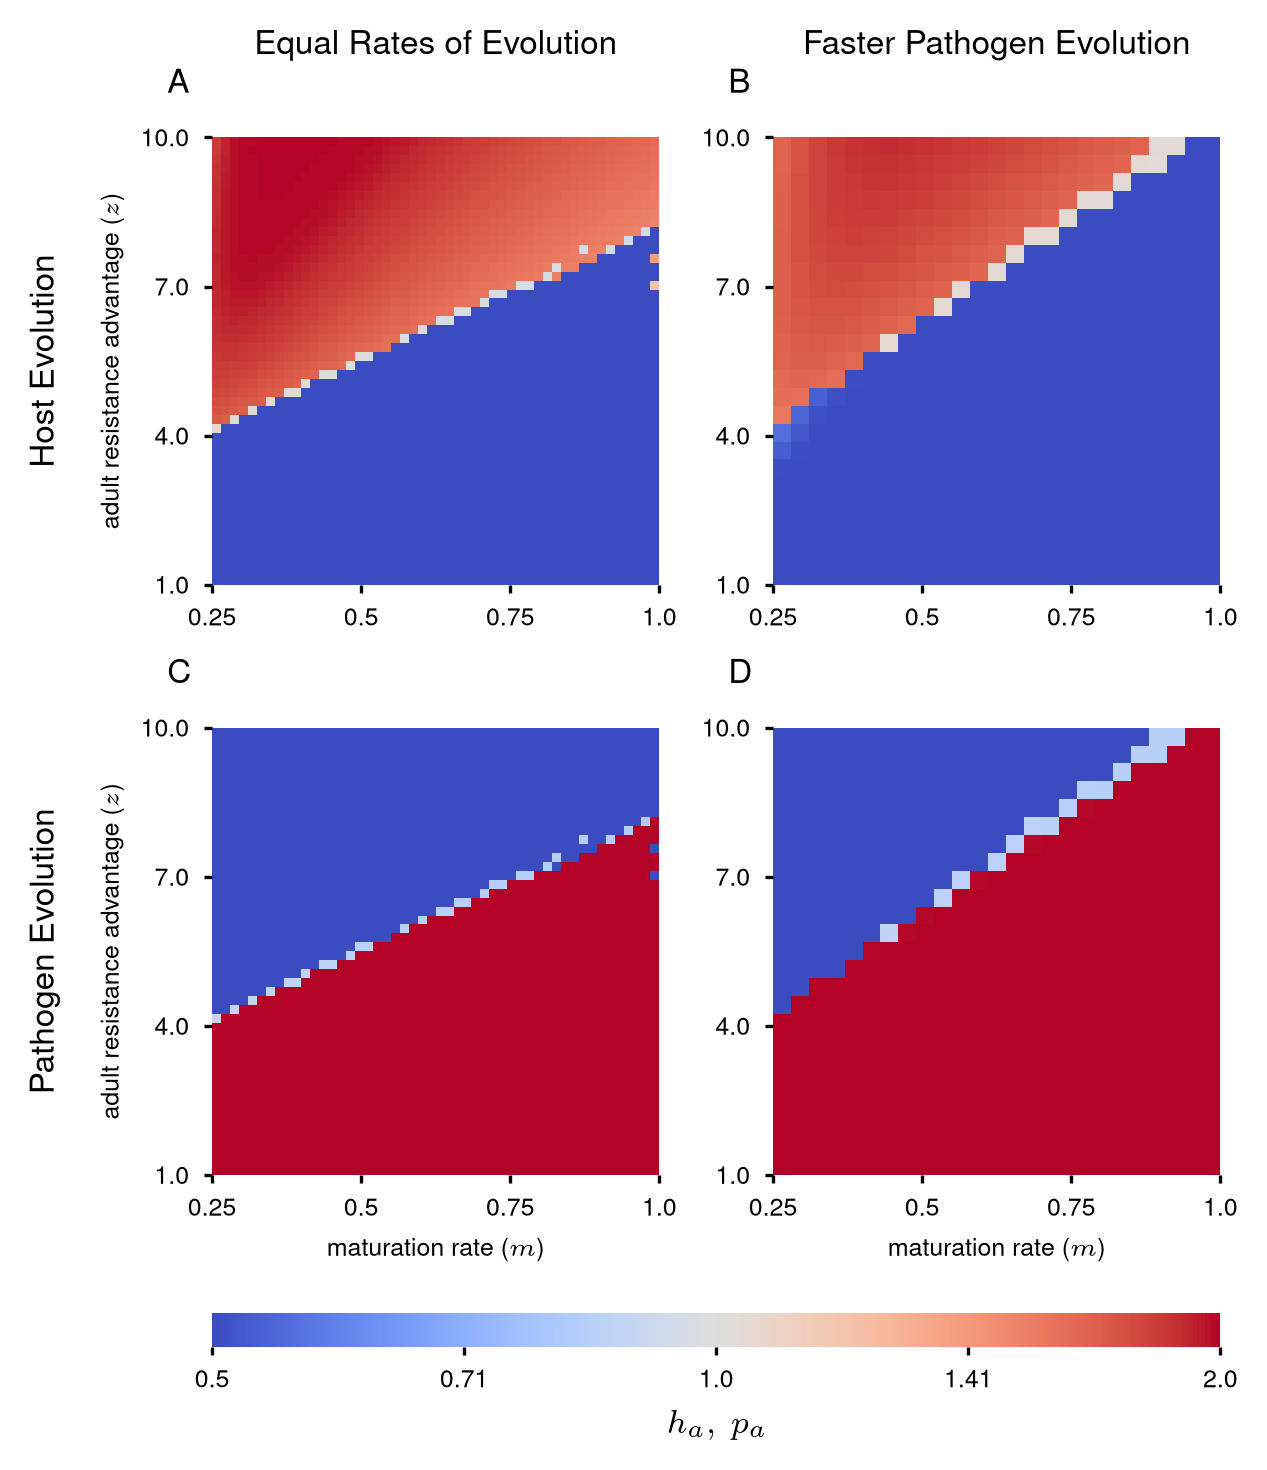

In [4]:
fig, ax = plt.subplots(ncols=2, nrows=2, layout='compressed')

S_coevol_default, I_coevol_default, = default_raster.evol_plot()
S_coevol_fast_evo, I_coevol_fast_evo, = fast_evo_raster.evol_plot()

plot = ax[0,0].imshow(99 - S_coevol_default, cmap='coolwarm', vmin=0, vmax=99)
ax[1,0].imshow(99 - I_coevol_default, cmap='coolwarm', vmin=0, vmax=99)

ax[0,1].imshow(99 - S_coevol_fast_evo, cmap='coolwarm', vmin=0, vmax=99)
ax[1,1].imshow(99 - I_coevol_fast_evo, cmap='coolwarm', vmin=0, vmax=99)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)

default_raster.label_axes(ax[0,0], (4, 4), label_x=False, label_y=True)
default_raster.label_axes(ax[1,0], (4, 4), label_y=True, x_string=r'maturation rate ($m$)')
fast_evo_raster.label_axes(ax[0,1], (4, 4), label_x=False, label_y=False)
fast_evo_raster.label_axes(ax[1,1], (4, 4), label_y=False, x_string=r'maturation rate ($m$)')

ax[0,0].set_title('Equal Rates of Evolution', pad=20, fontsize=8)
ax[0,1].set_title('Faster Pathogen Evolution', pad=20, fontsize=8)

ax[0,0].annotate('Host Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('Pathogen Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=8)
cbar.outline.set_visible(False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


# Figure S2: Alternative Trade-off Function #

In [5]:
#Load rasters and data used for raster plots
params_1 = {'m':0.8, 'mu':0.2, 'z':1, 'juv_trans':False, 'N_iter':500, 'tradeoff':'linear', 'beta':0.001}
params_2 = {'m':0.5, 'mu':0.2, 'z':5, 'juv_trans':False, 'N_iter':500, 'tradeoff':'linear', 'beta':0.001}
params_3 = {'m':0.2, 'mu':0.2, 'z':7, 'juv_trans':False, 'N_iter':500, 'tradeoff':'linear', 'beta':0.002}

host_model_1 = ModelAnalysis(mode='host', **params_1)
path_model_1 = ModelAnalysis(mode='path', **params_1)
coevol_model_1 = ModelAnalysis(mode='coevol', **params_1)

host_model_2 = ModelAnalysis(mode='host', **params_2)
path_model_2 = ModelAnalysis(mode='path', **params_2)
coevol_model_2 = ModelAnalysis(mode='coevol', **params_2)

host_model_3 = ModelAnalysis(mode='host', **params_3)
path_model_3 = ModelAnalysis(mode='path', **params_3)
coevol_model_3 = ModelAnalysis(mode='coevol', **params_3)

Sa_img_h1, Ia_img_h1, Sa_alpha_h1, Ia_alpha_h1 = make_image(host_model_1.Sa, host_model_1.Ia)
Sa_img_p1, Ia_img_p1, Sa_alpha_p1, Ia_alpha_p1 = make_image(path_model_1.Sa, path_model_1.Ia)
Sa_img_c1, Ia_img_c1, Sa_alpha_c1, Ia_alpha_c1 = make_image(coevol_model_1.Sa, coevol_model_1.Ia)

Sa_img_h2, Ia_img_h2, Sa_alpha_h2, Ia_alpha_h2 = make_image(host_model_2.Sa, host_model_2.Ia)
Sa_img_p2, Ia_img_p2, Sa_alpha_p2, Ia_alpha_p2 = make_image(path_model_2.Sa, path_model_2.Ia)
Sa_img_c2, Ia_img_c2, Sa_alpha_c2, Ia_alpha_c2 = make_image(coevol_model_2.Sa, coevol_model_2.Ia)

Sa_img_h3, Ia_img_h3, Sa_alpha_h3, Ia_alpha_h3 = make_image(host_model_3.Sa, host_model_3.Ia)
Sa_img_p3, Ia_img_p3, Sa_alpha_p3, Ia_alpha_p3 = make_image(path_model_3.Sa, path_model_3.Ia)
Sa_img_c3, Ia_img_c3, Sa_alpha_c3, Ia_alpha_c3 = make_image(coevol_model_3.Sa, coevol_model_3.Ia)

Text(-0.1, 1.1, 'I')

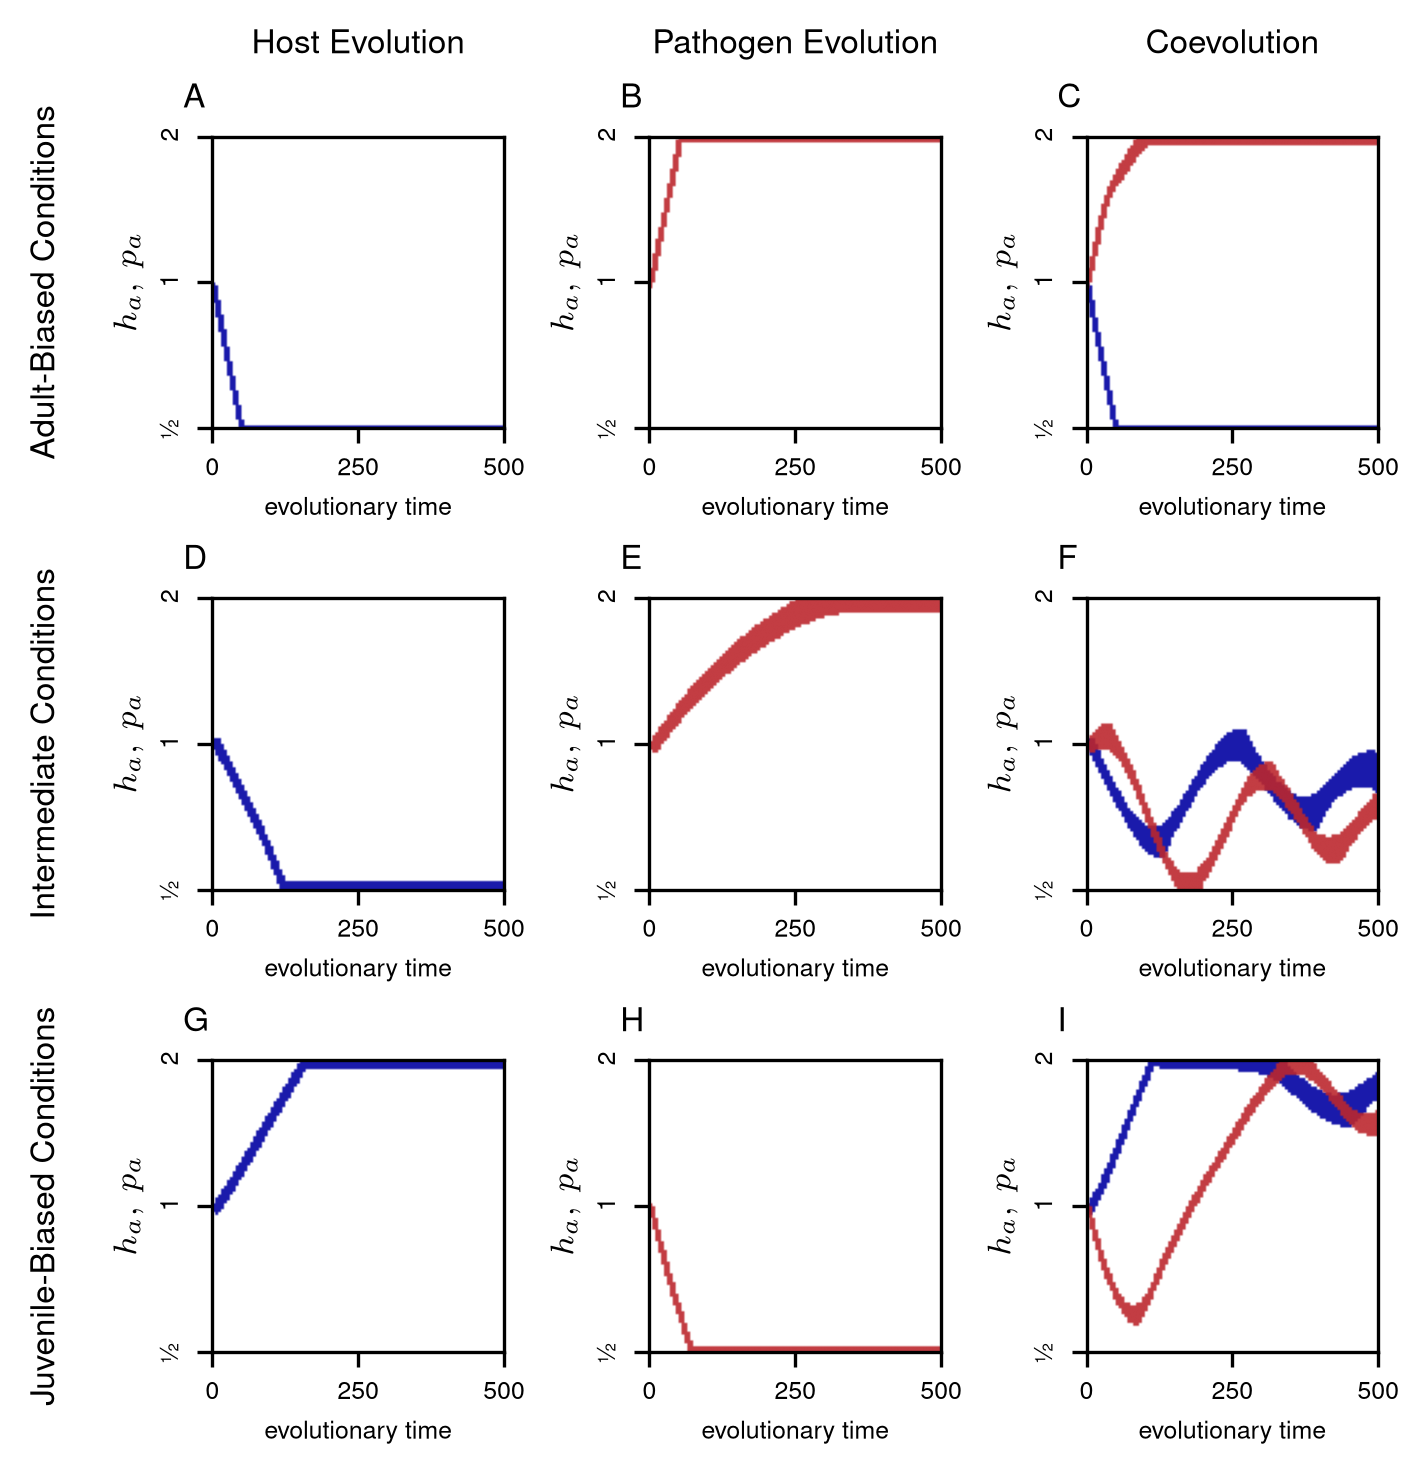

In [6]:
fig, ax = plt.subplots(ncols=3, nrows=3, layout='compressed')

ax[0,0].imshow(Sa_img_h1, alpha=Sa_alpha_h1, cmap=s_cmap)
ax[0,1].imshow(Ia_img_p1, alpha=Ia_alpha_p1, cmap=i_cmap)
ax[0,2].imshow(Sa_img_c1, alpha=Sa_alpha_c1, cmap=s_cmap)
ax[0,2].imshow(Ia_img_c1, alpha=Ia_alpha_c1, cmap=i_cmap)

ax[1,0].imshow(Sa_img_h2, alpha=Sa_alpha_h2, cmap=s_cmap)
ax[1,1].imshow(Ia_img_p2, alpha=Ia_alpha_p2, cmap=i_cmap)
ax[1,2].imshow(Sa_img_c2, alpha=Sa_alpha_c2, cmap=s_cmap)
ax[1,2].imshow(Ia_img_c2, alpha=Ia_alpha_c2, cmap=i_cmap)

ax[2,0].imshow(Sa_img_h3, alpha=Sa_alpha_h3, cmap=s_cmap)
ax[2,1].imshow(Ia_img_p3, alpha=Ia_alpha_p3, cmap=i_cmap)
ax[2,2].imshow(Sa_img_c3, alpha=Sa_alpha_c3, cmap=s_cmap)
ax[2,2].imshow(Ia_img_c3, alpha=Ia_alpha_c3, cmap=i_cmap)

ax[0,0].set_title('Host Evolution', pad=20, fontsize=8)
ax[0,1].set_title('Pathogen Evolution', pad=20, fontsize=8)
ax[0,2].set_title('Coevolution', pad=20, fontsize=8)

ax[0,0].annotate('Adult-Biased Conditions', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('Intermediate Conditions', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[2,0].annotate('Juvenile-Biased Conditions', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, host_model_1.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

for axis in ax.reshape(-1): 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)

    ax_tick_pos = np.linspace(axis.get_ylim()[0], axis.get_ylim()[1], 3)
    ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']
    axis.set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)

    axis.set_xlabel(r'evolutionary time')
    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, host_model_1.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=8)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=8)
ax[0,2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=8)
ax[1,0].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=8)
ax[1,1].annotate("E", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=8)
ax[1,2].annotate("F", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=8)
ax[2,0].annotate("G", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=8)
ax[2,1].annotate("H", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=8)
ax[2,2].annotate("I", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=8)

# Figure S3: Higher Baseline Transmission #

In [7]:
host_path = 'data/high_trans_init_50_host.p'
path_path = 'data/high_trans_init_50_path.p'
coevol_path = 'data/high_trans_init_50_coevol.p'

host_raster = RasterAnalysis(host_path, arg_x='m', arg_y='z')
path_raster = RasterAnalysis(path_path, arg_x='m', arg_y='z')
coevol_raster = RasterAnalysis(coevol_path, arg_x='m', arg_y='z')

/tmp/ipykernel_301194/3593161396.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])


Text(-0.1, 1.1, 'D')

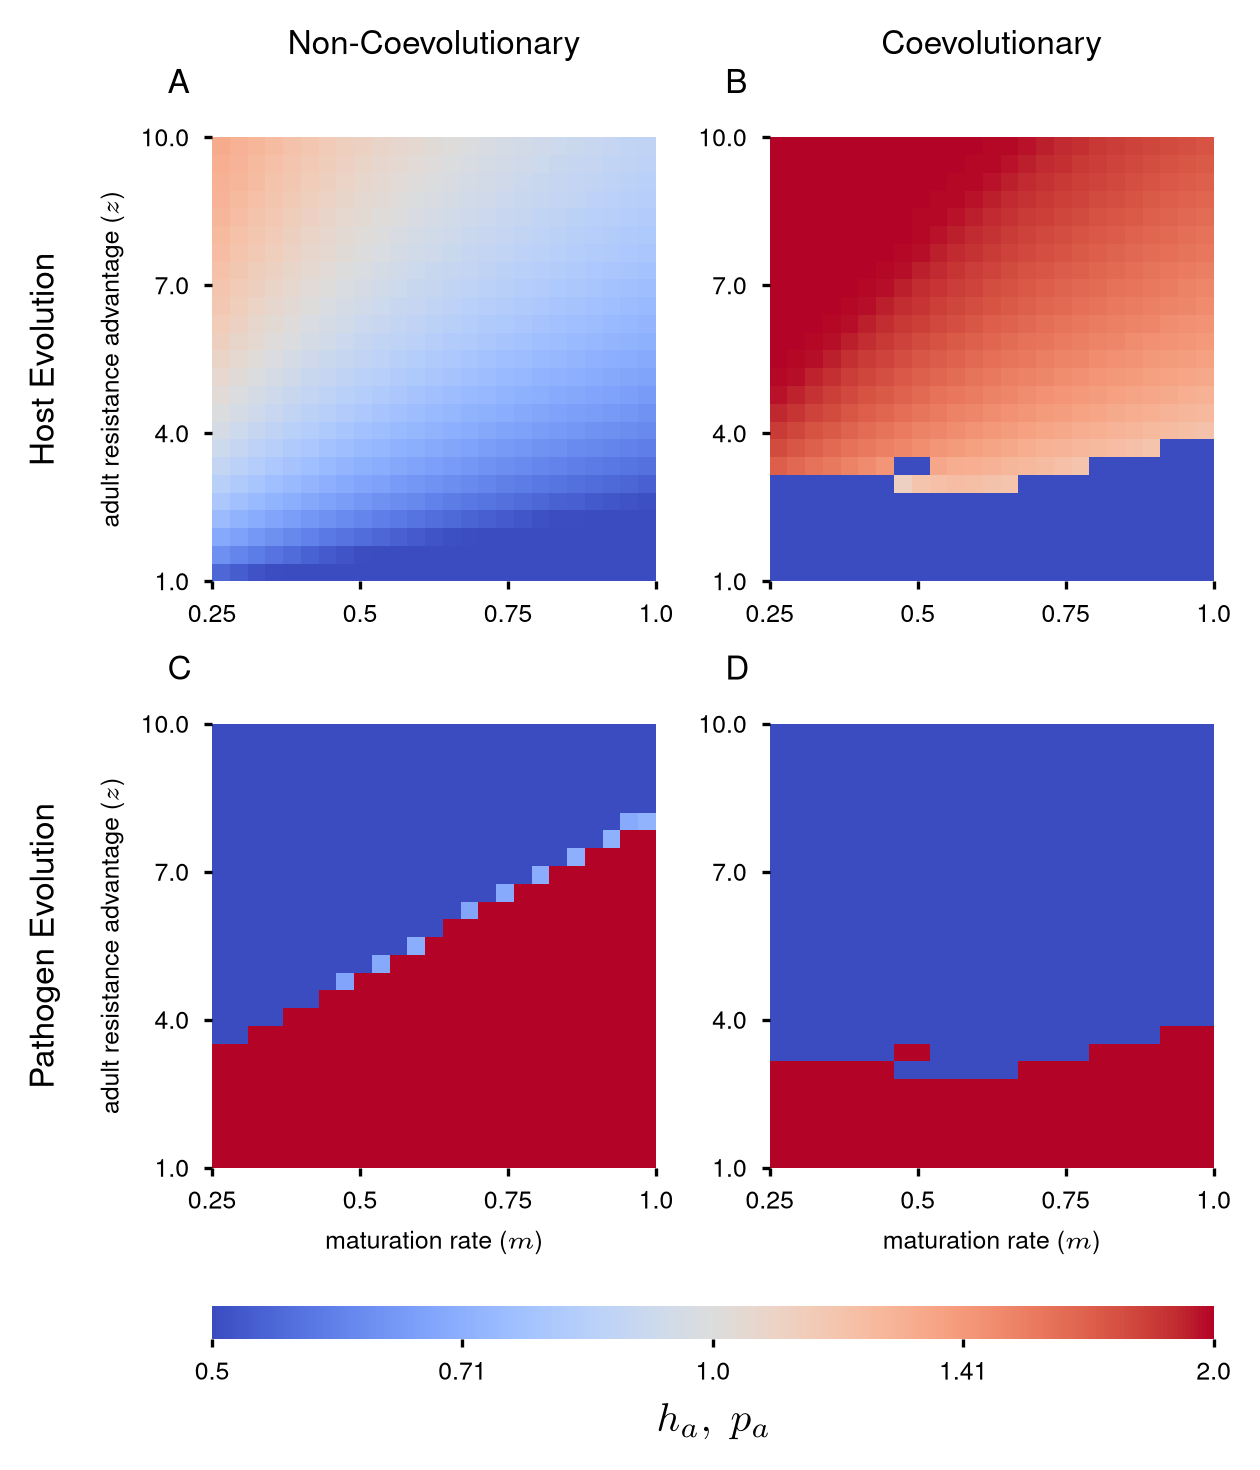

In [9]:
fig, ax = plt.subplots(ncols=2, nrows=2, layout='compressed')

S_host, I_host, = host_raster.evol_plot()
S_path, I_path, = path_raster.evol_plot()
S_coevol, I_coevol, = coevol_raster.evol_plot()

plot = ax[0,0].imshow(99 - S_host, cmap='coolwarm', vmin=0, vmax=99)
ax[1,0].imshow(99 - I_path, cmap='coolwarm', vmin=0, vmax=99)

ax[0,1].imshow(99 - S_coevol, cmap='coolwarm', vmin=0, vmax=99)
ax[1,1].imshow(99 - I_coevol, cmap='coolwarm', vmin=0, vmax=99)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)

default_raster.label_axes(ax[0,0], (4, 4), label_x=False, label_y=True)
default_raster.label_axes(ax[1,0], (4, 4), label_y=True, x_string=r'maturation rate ($m$)')
fast_evo_raster.label_axes(ax[0,1], (4, 4), label_x=False, label_y=False)
fast_evo_raster.label_axes(ax[1,1], (4, 4), label_y=False, x_string=r'maturation rate ($m$)')

ax[0,0].set_title('Non-Coevolutionary', pad=20, fontsize=8)
ax[0,1].set_title('Coevolutionary', pad=20, fontsize=8)

ax[0,0].annotate('Host Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('Pathogen Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=10)
cbar.outline.set_visible(False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


# Figure S4: Mortality Inducing Virulence #

In [11]:
host_path = 'data/mortality_inducing_init_50_host.p'
path_path = 'data/mortality_inducing_init_50_path.p'
coevol_path = 'data/mortality_inducing_init_50_coevol.p'

host_raster = RasterAnalysis(host_path, arg_x='m', arg_y='z')
path_raster = RasterAnalysis(path_path, arg_x='m', arg_y='z')
coevol_raster = RasterAnalysis(coevol_path, arg_x='m', arg_y='z')

/home/sam/Projects/transmission-coevolution/model_tools.py:43: RuntimeWarning: invalid value encountered in scalar divide
  path_evol[y_ind, x_ind] = np.dot(Ia[:,-1], range(Ia.shape[0])) / np.sum(Ia[:, -1])
/tmp/ipykernel_301194/151045906.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])


Text(-0.1, 1.1, 'D')

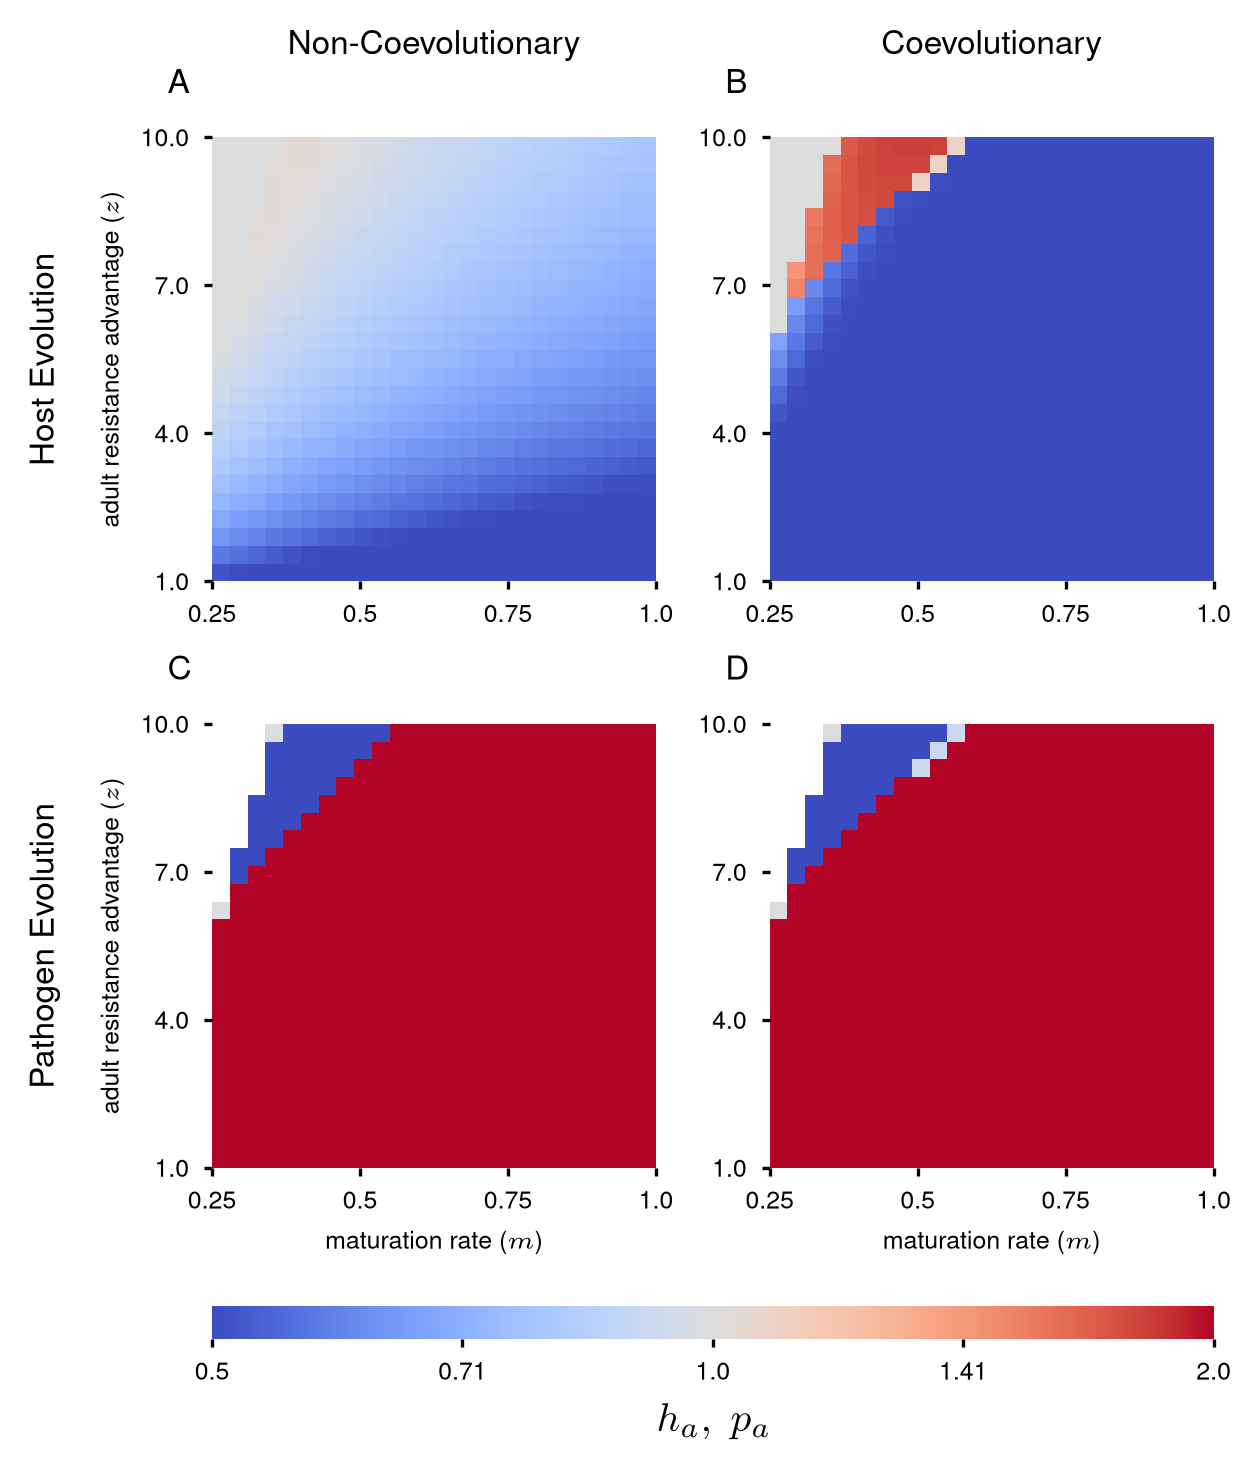

In [12]:
fig, ax = plt.subplots(ncols=2, nrows=2, layout='compressed')

S_host, I_host, = host_raster.evol_plot()
S_path, I_path, = path_raster.evol_plot()
S_coevol, I_coevol, = coevol_raster.evol_plot()

plot = ax[0,0].imshow(99 - S_host, cmap='coolwarm', vmin=0, vmax=99)
ax[1,0].imshow(99 - I_path, cmap='coolwarm', vmin=0, vmax=99)

ax[0,1].imshow(99 - S_coevol, cmap='coolwarm', vmin=0, vmax=99)
ax[1,1].imshow(99 - I_coevol, cmap='coolwarm', vmin=0, vmax=99)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)

host_raster.label_axes(ax[0,0], (4, 4), label_x=False, label_y=True)
path_raster.label_axes(ax[1,0], (4, 4), label_x=True, label_y=True, x_string=r'maturation rate ($m$)')
coevol_raster.label_axes(ax[0,1], (4, 4), label_x=False, label_y=False)
coevol_raster.label_axes(ax[1,1], (4, 4), label_y=False, x_string=r'maturation rate ($m$)')

ax[0,0].set_title('Non-Coevolutionary', pad=20, fontsize=8)
ax[0,1].set_title('Coevolutionary', pad=20, fontsize=8)

ax[0,0].annotate('Host Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('Pathogen Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=10)
cbar.outline.set_visible(False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


# Figure S5: Effects of Initial Conditions #

In [2]:
host_path = 'data/default_init_50_host.p'
path_path = 'data/default_init_50_path.p'
coevol_path_60 = 'data/default_init_60_coevol.p'
coevol_path_50 = 'data/default_init_40_coevol.p'

host_raster = RasterAnalysis(host_path, arg_x='m', arg_y='z')
path_raster = RasterAnalysis(path_path, arg_x='m', arg_y='z')
coevol_raster_60 = RasterAnalysis(coevol_path_60, arg_x='m', arg_y='z')
coevol_raster_50 = RasterAnalysis(coevol_path_50, arg_x='m', arg_y='z')

/tmp/ipykernel_311128/4171222938.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])


Text(-0.1, 1.1, 'F')

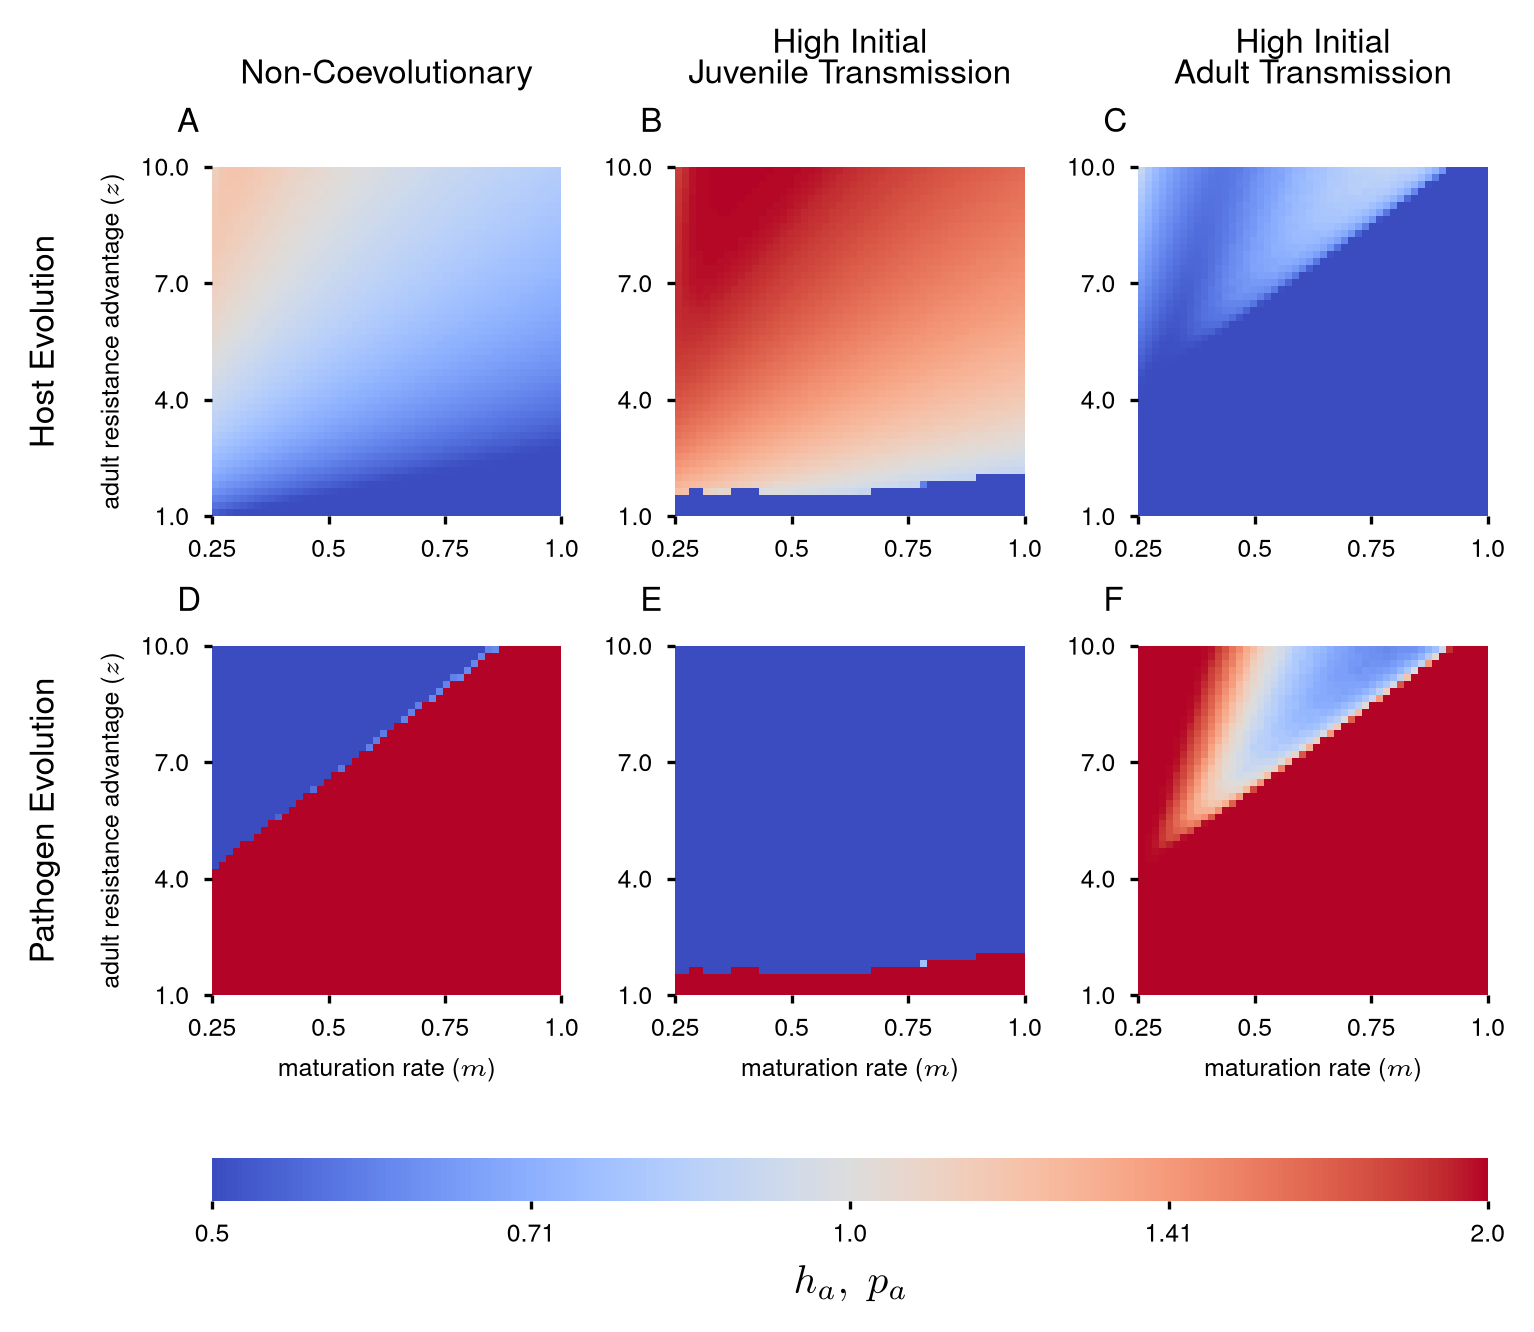

In [4]:
fig, ax = plt.subplots(figsize=(5,5), ncols=3, nrows=2, layout='compressed')

S_host, I_host = host_raster.evol_plot()
S_path, I_path = path_raster.evol_plot()
S_coevol_60, I_coevol_60, = coevol_raster_60.evol_plot()
S_coevol_50, I_coevol_50, = coevol_raster_50.evol_plot()

plot = ax[0,0].imshow(99 - S_host, cmap='coolwarm', vmin=0, vmax=99)
plot = ax[1,0].imshow(99 - I_path, cmap='coolwarm', vmin=0, vmax=99)

ax[0,1].imshow(99 - S_coevol_60, cmap='coolwarm', vmin=0, vmax=99)
ax[1,1].imshow(99 - I_coevol_60, cmap='coolwarm', vmin=0, vmax=99)

plot = ax[0,2].imshow(99 - S_coevol_50, cmap='coolwarm', vmin=0, vmax=99)
ax[1,2].imshow(99 - I_coevol_50, cmap='coolwarm', vmin=0, vmax=99)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)

coevol_raster_60.label_axes(ax[0,0], (4, 4), label_x=False, label_y=True)
coevol_raster_60.label_axes(ax[1,0], (4, 4), label_y=True, x_string=r'maturation rate ($m$)')
coevol_raster_50.label_axes(ax[0,1], (4, 4), label_x=False, label_y=False)
coevol_raster_50.label_axes(ax[1,1], (4, 4), label_y=False, x_string=r'maturation rate ($m$)')
coevol_raster_60.label_axes(ax[0,2], (4, 4), label_x=False, label_y=False)
coevol_raster_60.label_axes(ax[1,2], (4, 4), label_y=False, x_string=r'maturation rate ($m$)')

ax[0,0].set_title('Non-Coevolutionary', pad=20, fontsize=8)
ax[0,1].set_title('High Initial\nJuvenile Transmission', pad=20, fontsize=8)
ax[0,2].set_title('High Initial\nAdult Transmission', pad=20, fontsize=8)

ax[0,0].annotate('Host Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('Pathogen Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=10)
cbar.outline.set_visible(False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("E", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,2].annotate("F", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


# Figure S6: Initial conditions can lead to different evolutionary trajectories #

In [13]:
params_1 = {'m':0.35, 'z':10, 'mu':0.2, 'juv_trans':False, 'N_iter':600,'S_gtp0':40, 'I_gtp0':40}
params_2 = {'m':0.35, 'z':10, 'mu':0.2, 'juv_trans':False, 'N_iter':600,'S_gtp0':60, 'I_gtp0':60}

model_1 = ModelAnalysis(mode='coevol', **params_1)
model_2 = ModelAnalysis(mode='coevol', **params_2)

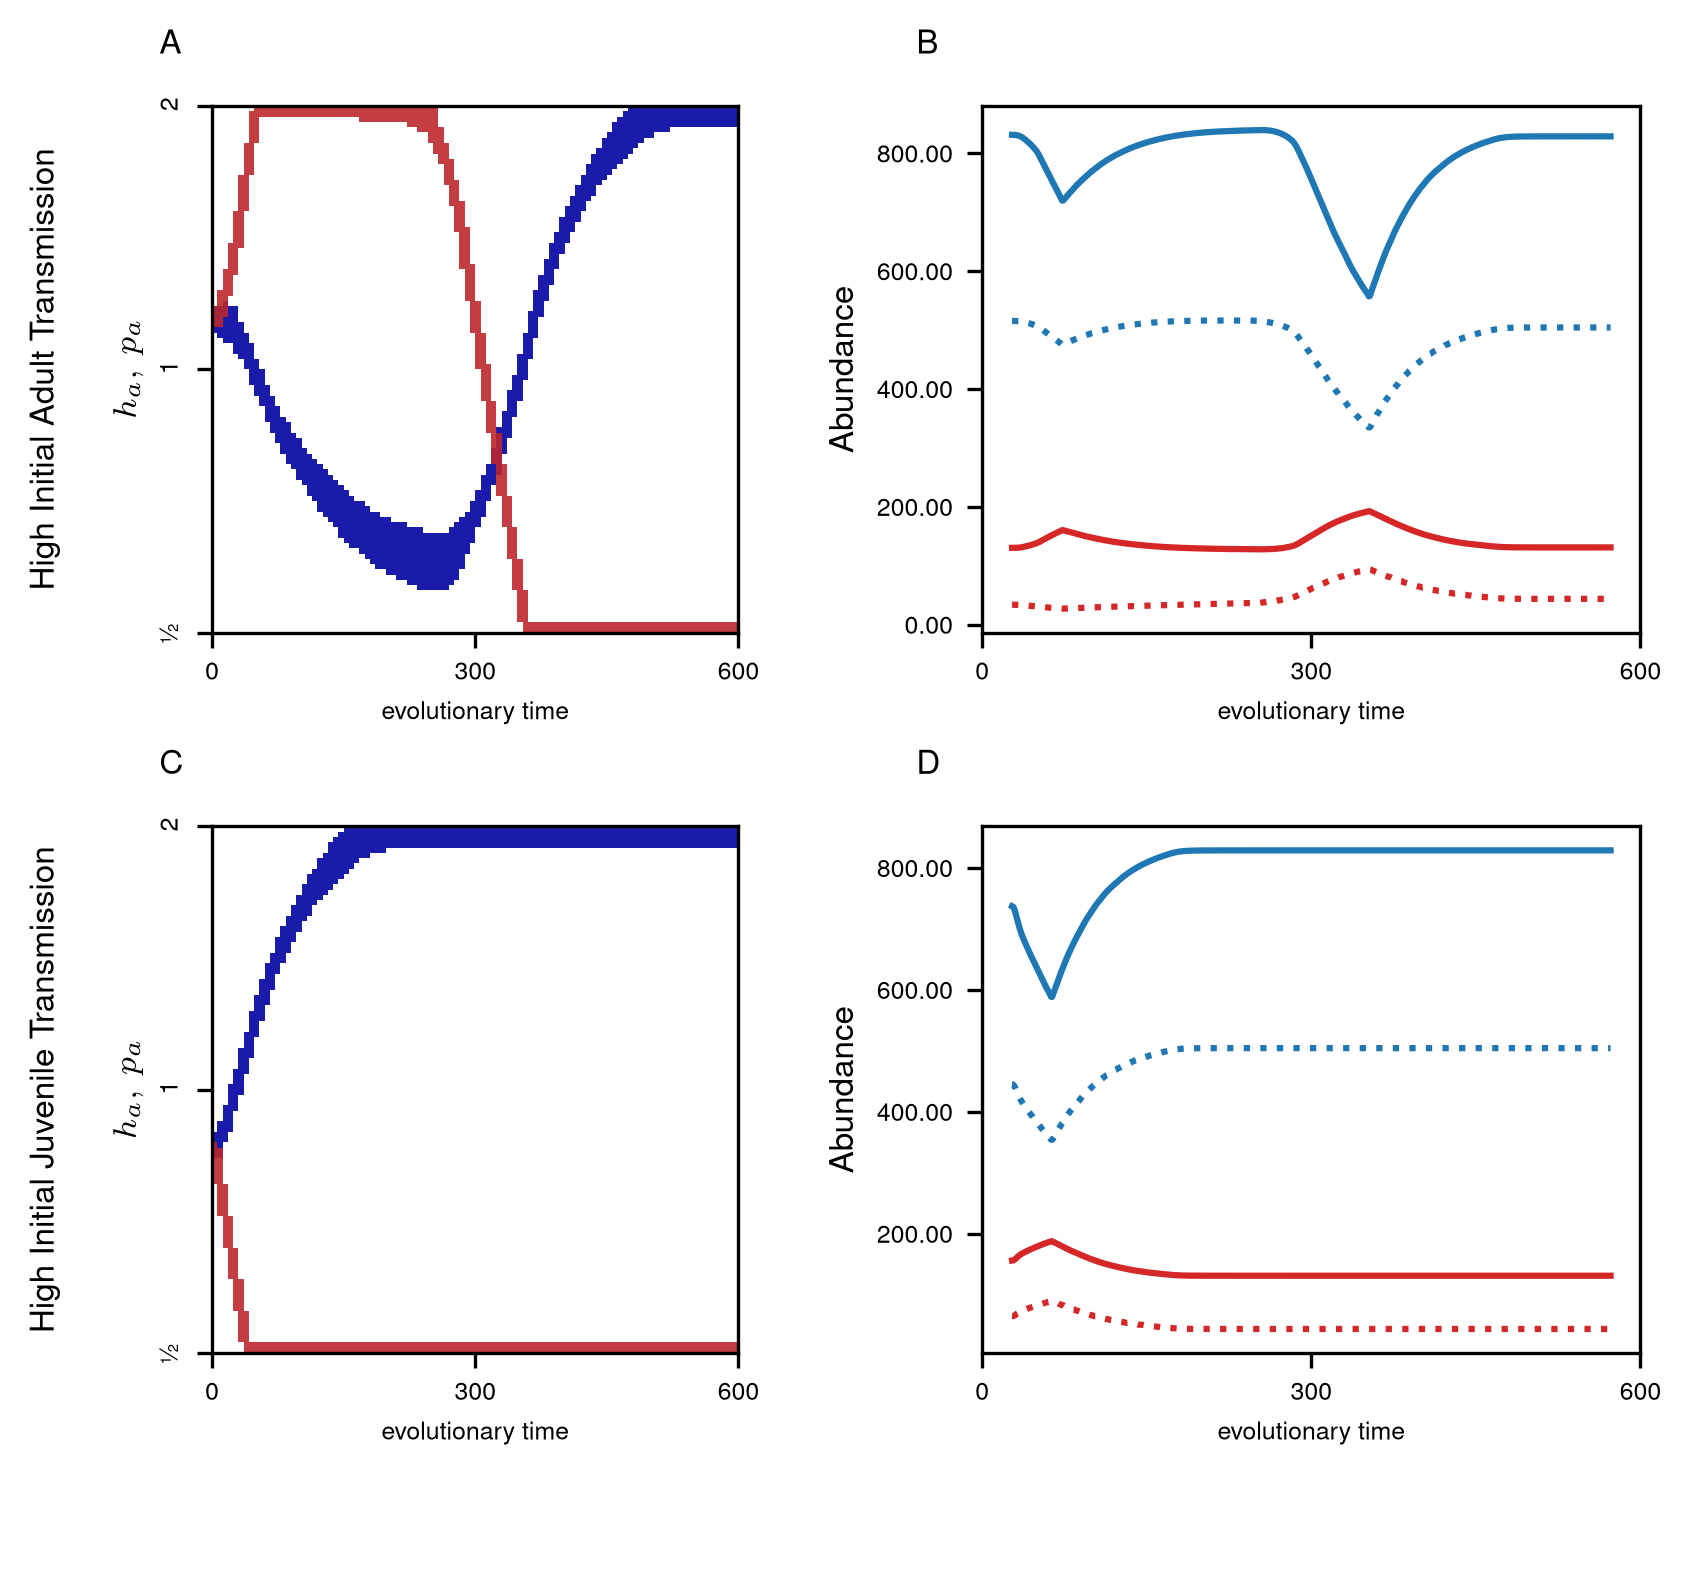

In [14]:
fig, ax = plt.subplots(ncols=2, nrows=2, layout='compressed')

cmap = matplotlib.colormaps['Blues']

Sa_img_1, Ia_img_1, Sa_alpha_1, Ia_alpha_1 = make_image(model_1.Sa, model_1.Ia)
Sa_img_2, Ia_img_2, Sa_alpha_2, Ia_alpha_2 = make_image(model_2.Sa, model_2.Ia)

ax[0,0].imshow(Sa_img_1, alpha=Sa_alpha_1, cmap=s_cmap)
ax[0,0].imshow(Ia_img_1, alpha=Ia_alpha_1, cmap=i_cmap)
ax[1,0].imshow(Sa_img_2, alpha=Sa_alpha_2, cmap=s_cmap)
ax[1,0].imshow(Ia_img_2, alpha=Ia_alpha_2, cmap=i_cmap)

ax[0,1].plot(np.sum(model_1.Sj, axis=0), color='tab:blue', linestyle=':')
ax[0,1].plot(np.sum(model_1.Sa, axis=0), color='tab:blue')
ax[0,1].plot(np.sum(model_1.Ij, axis=0), color='tab:red', linestyle=':')
ax[0,1].plot(np.sum(model_1.Ia, axis=0), color='tab:red')

ax[1,1].plot(np.sum(model_2.Sj, axis=0), color='tab:blue', linestyle=':', label=r'$S_j$')
ax[1,1].plot(np.sum(model_2.Sa, axis=0), color='tab:blue', label=r'$S_a$')
ax[1,1].plot(np.sum(model_2.Ij, axis=0), color='tab:red', linestyle=':', label=r'$I_j$')
ax[1,1].plot(np.sum(model_2.Ia, axis=0), color='tab:red', label=r'$I_a$')

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, model_1.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

for axis in ax[:,0]: 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)

    ax_tick_pos = np.linspace(axis.get_ylim()[0], axis.get_ylim()[1], 3)
    ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']
    axis.set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)

    axis.set_xlabel(r'evolutionary time')
    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)

for axis in ax[:,1]: 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)

    axis.set_xlabel(r'evolutionary time')
    axis.set_ylabel(r'Abundance', fontsize=8)

ax[0,0].annotate('High Initial Adult Transmission', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('High Initial Juvenile Transmission', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

lines, labels = ax[0,1].get_legend_handles_labels()
fig.legend(lines, labels, ncol=4, loc='center', bbox_to_anchor=(0.5, -0.05), frameon=False)

# Figure S7: Evolutionary Effects of the Mortality Rates #

In [15]:
host_path = 'data/variable_mu_init_50_host.p'
path_path = 'data/variable_mu_init_50_path.p'
coevol_path = 'data/variable_mu_init_50_coevol.p'

host_raster = RasterAnalysis(host_path, arg_x='mu', arg_y='z')
path_raster = RasterAnalysis(path_path, arg_x='mu', arg_y='z')
coevol_raster = RasterAnalysis(coevol_path, arg_x='mu', arg_y='z')

/home/sam/Projects/transmission-coevolution/model_tools.py:43: RuntimeWarning: invalid value encountered in scalar divide
  path_evol[y_ind, x_ind] = np.dot(Ia[:,-1], range(Ia.shape[0])) / np.sum(Ia[:, -1])
/tmp/ipykernel_301194/1402476966.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])


Text(-0.1, 1.1, 'D')

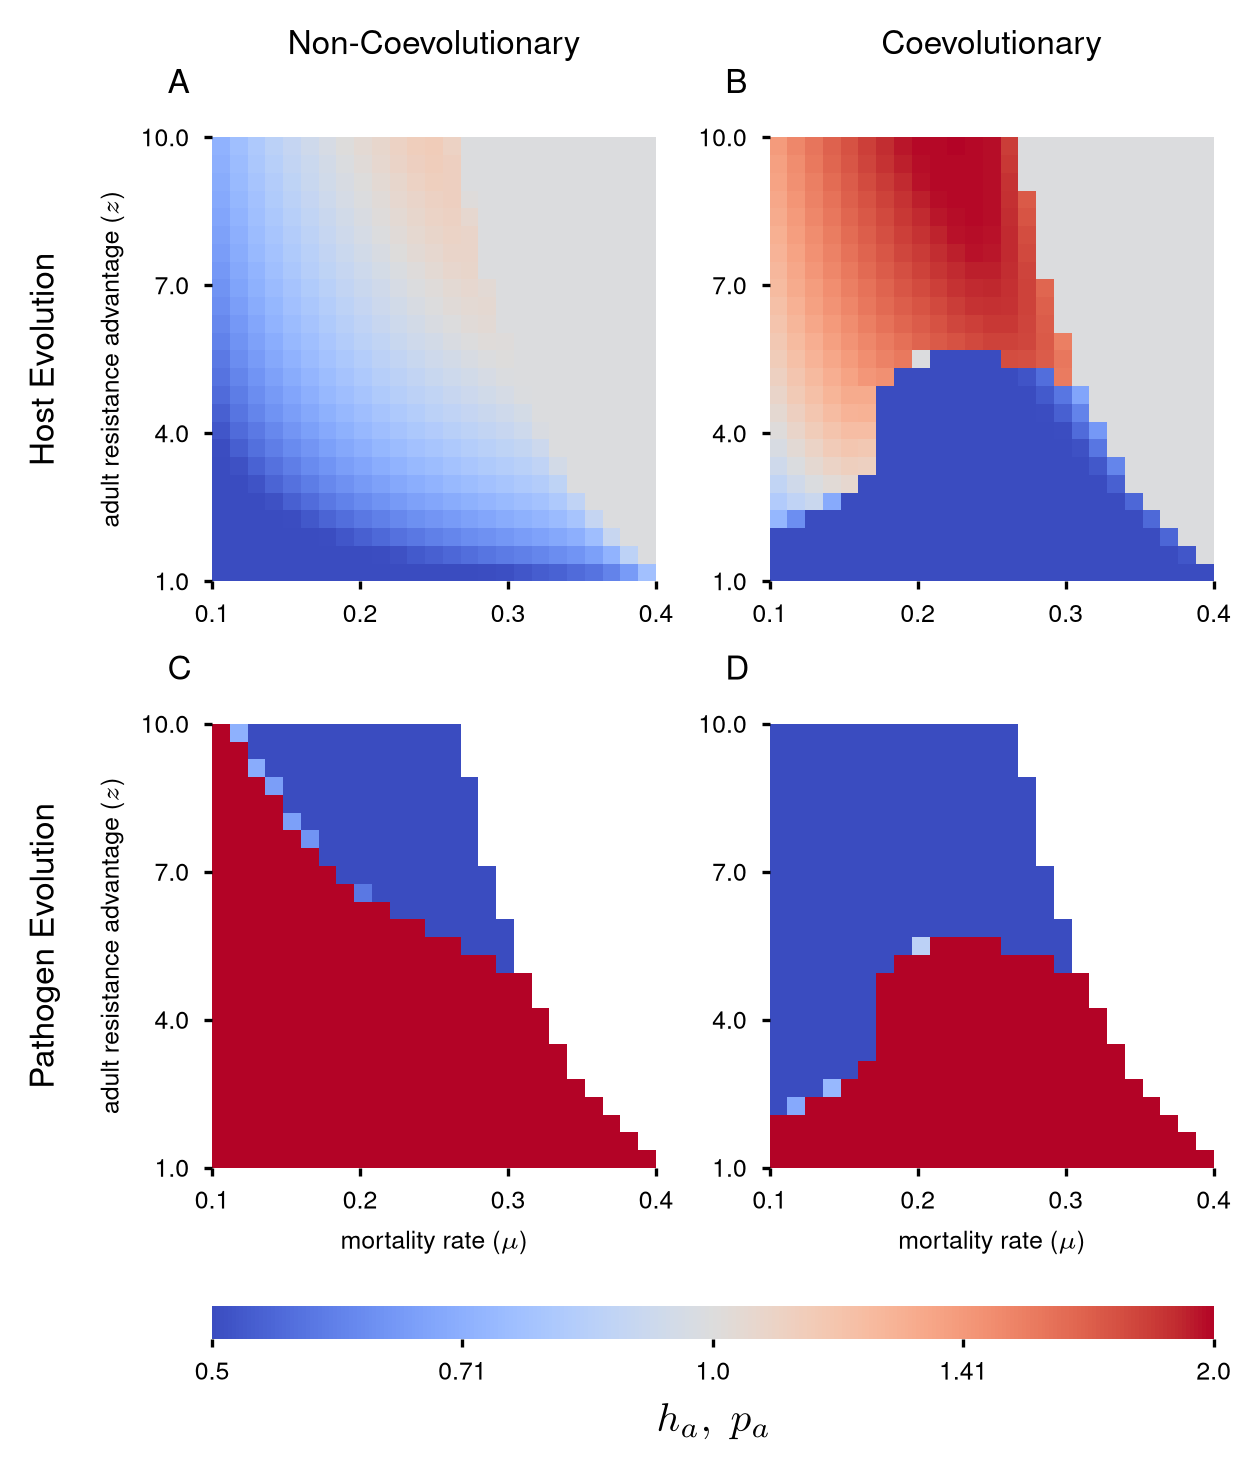

In [17]:
fig, ax = plt.subplots(ncols=2, nrows=2, layout='compressed')

S_host, I_host, = host_raster.evol_plot()
S_path, I_path, = path_raster.evol_plot()
S_coevol, I_coevol, = coevol_raster.evol_plot()

plot = ax[0,0].imshow(99 - S_host, cmap='coolwarm', vmin=0, vmax=99)
ax[1,0].imshow(99 - I_path, cmap='coolwarm', vmin=0, vmax=99)

ax[0,1].imshow(99 - S_coevol, cmap='coolwarm', vmin=0, vmax=99)
ax[1,1].imshow(99 - I_coevol, cmap='coolwarm', vmin=0, vmax=99)

for axis in ax.reshape(-1):
    axis.invert_yaxis()
    axis.set_frame_on(False)
    axis.tick_params('both', length=2)

host_raster.label_axes(ax[0,0], (4, 4), label_x=False, label_y=True)
path_raster.label_axes(ax[1,0], (4, 4), label_x=True, label_y=True, x_string=r'mortality rate ($\mu$)')
coevol_raster.label_axes(ax[0,1], (4, 4), label_x=False, label_y=False)
coevol_raster.label_axes(ax[1,1], (4, 4), label_y=False, x_string=r'mortality rate ($\mu$)')

ax[0,0].set_title('Non-Coevolutionary', pad=20, fontsize=8)
ax[0,1].set_title('Coevolutionary', pad=20, fontsize=8)

ax[0,0].annotate('Host Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('Pathogen Evolution', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

cbar = fig.colorbar(plot, ax=ax[:], location='bottom', aspect=30)
cbar.ax.set_xticklabels(['Low Juvenile Transmission \n High Adult Transmission', 'High Juvenile Transmission \n Low Adult Transmission'])
cbar.ax.tick_params(axis='both', which='both', length=2)
cbar.ax.set_xticks(np.linspace(0, 99, 5))
cbar.ax.set_xticklabels(np.round(np.logspace(-1, 1, 5, base=2), 2))
cbar.set_label(r'$h_a,\ p_a$', fontsize=10)
cbar.outline.set_visible(False)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)


# Figure S8: Demographic Effects of Mortality Rates #

In [18]:
host_path = 'data/variable_mu_init_50_host.p'
path_path = 'data/variable_mu_init_50_path.p'
coevol_path = 'data/variable_mu_init_50_coevol.p'

host_raster = RasterAnalysis(host_path, arg_x='mu', arg_y='z')
path_raster = RasterAnalysis(path_path, arg_x='mu', arg_y='z')
coevol_raster = RasterAnalysis(coevol_path, arg_x='mu', arg_y='z')

/tmp/ipykernel_301194/3616528436.py:24: RuntimeWarning: invalid value encountered in divide
  host_ratio = np.log10(betaj_host / betaa_host)
/tmp/ipykernel_301194/3616528436.py:25: RuntimeWarning: invalid value encountered in divide
  path_ratio = np.log10(betaj_path / betaa_path)
/tmp/ipykernel_301194/3616528436.py:26: RuntimeWarning: invalid value encountered in divide
  coevol_ratio = np.log10(betaj_coevol / betaa_coevol)


Text(-0.1, 1.1, 'F')

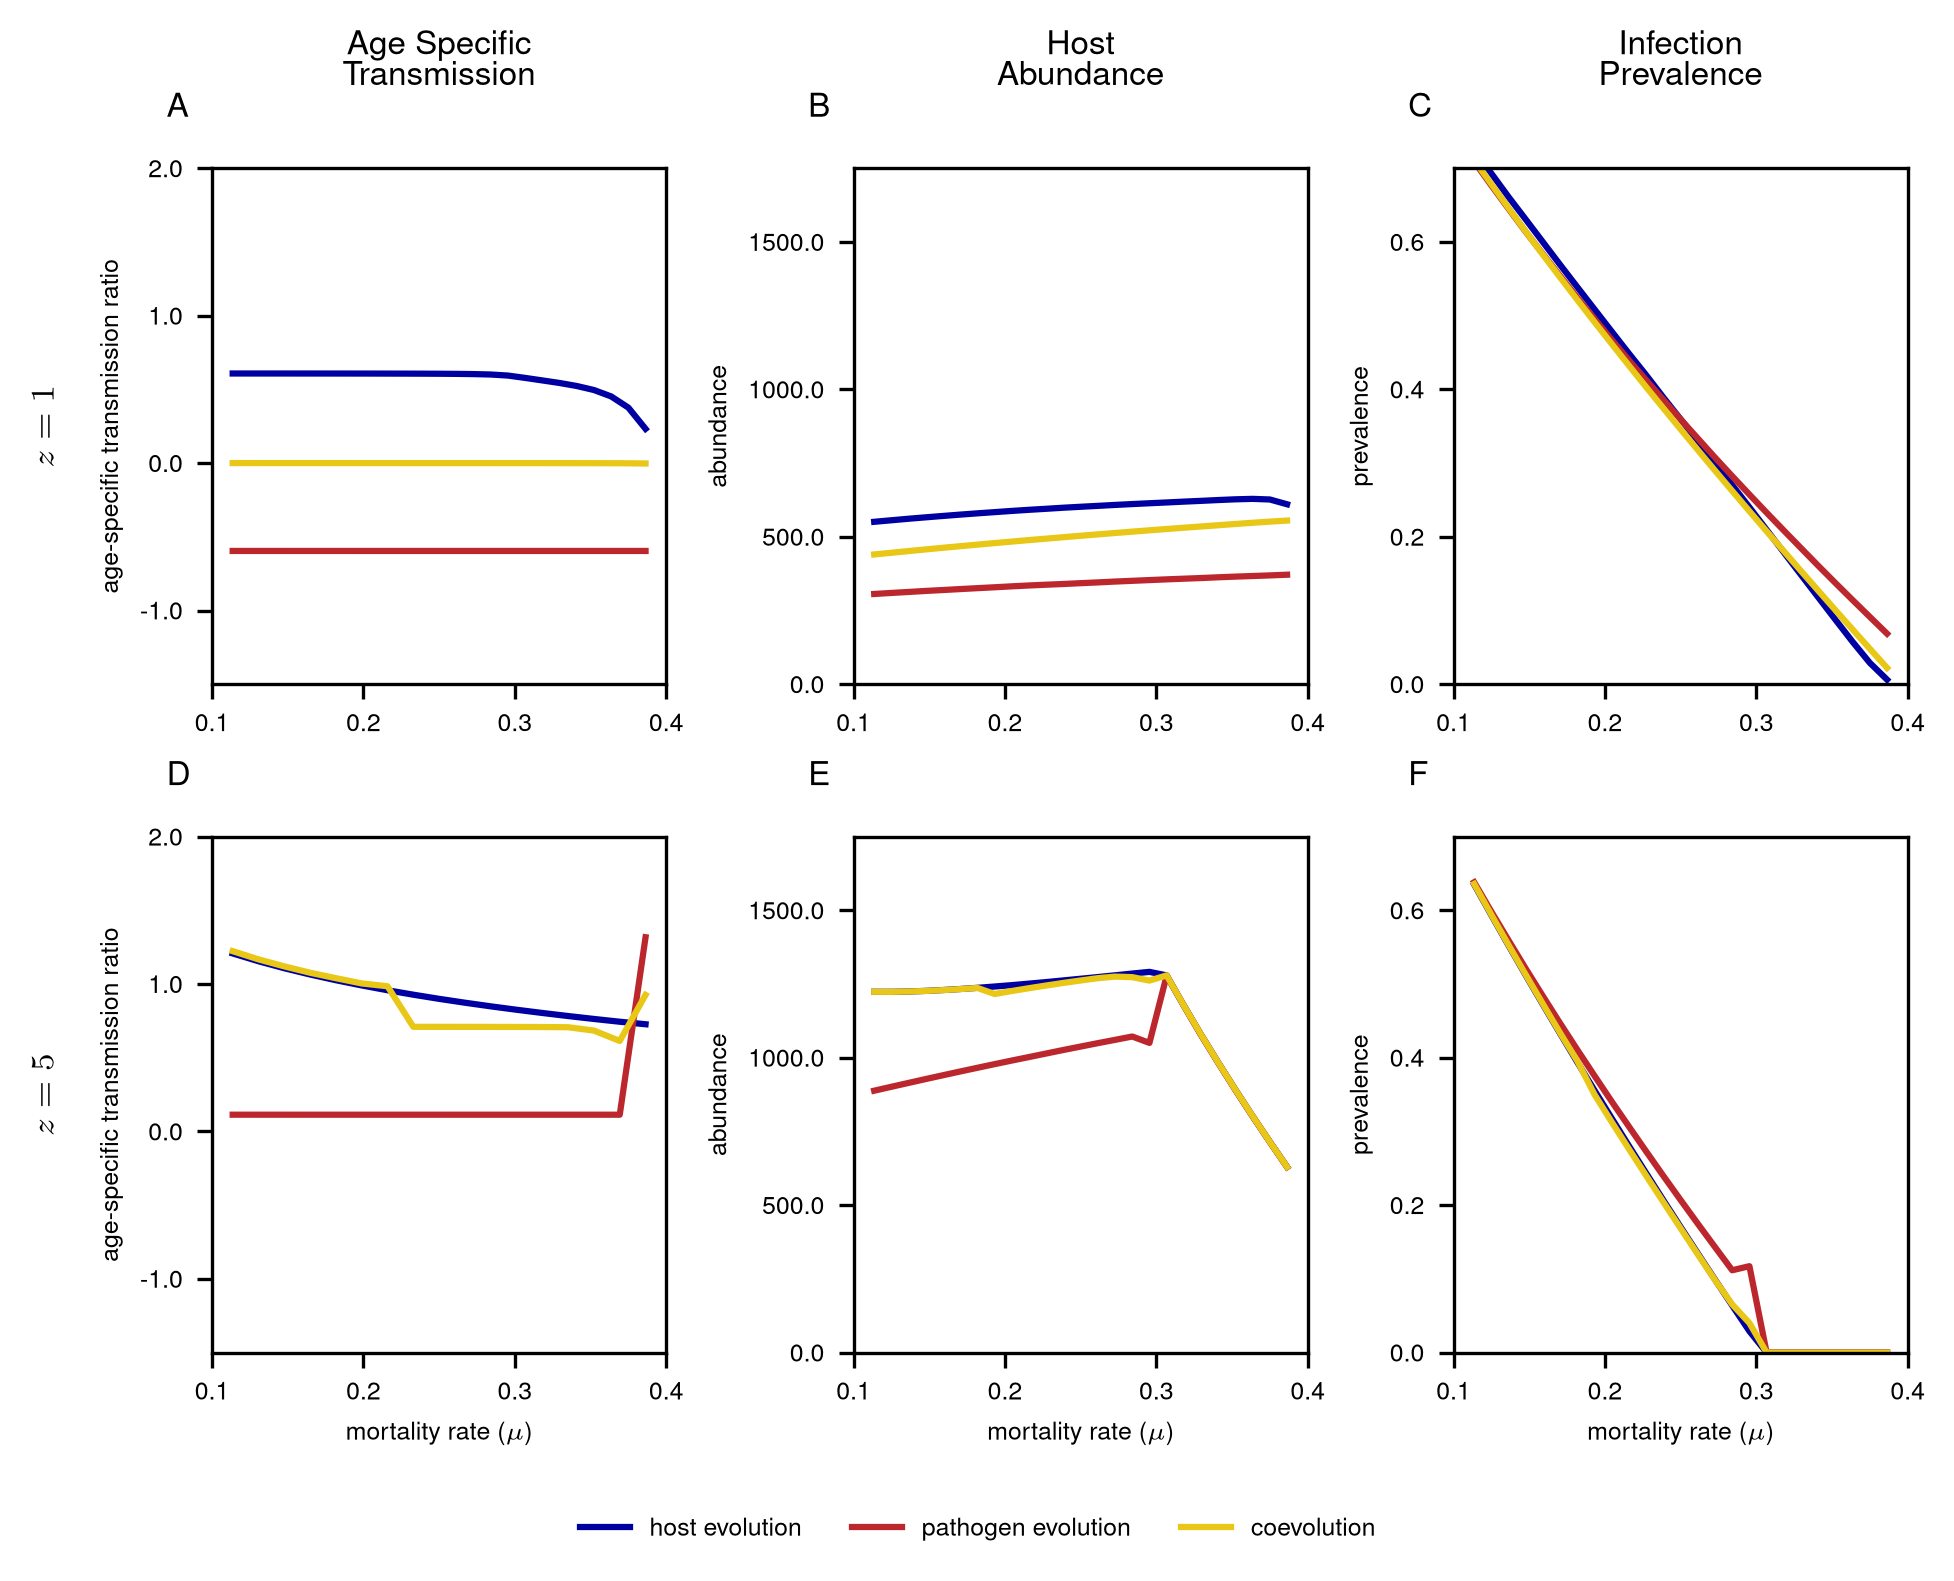

In [19]:
fig, ax = plt.subplots(ncols=3, nrows=2, layout='compressed')

z_1 = 1
z_2 = 5

ind_1 = np.argmin((coevol_raster.y_vals - z_1)**2)
ind_2 = np.argmin((coevol_raster.y_vals - z_2)**2)

inds = [ind_1, ind_2]

def label_xaxis(ax, n_ticks=4):
    m_vals = coevol_raster.x_vals
    x_lim = ax.get_xlim()

    x_ticks = np.linspace(x_lim[0], x_lim[1], n_ticks)
    x_tick_labels = np.round(np.linspace(np.min(m_vals), np.max(m_vals), n_ticks), 3)
    
    ax.set_xticks(x_ticks, x_tick_labels)

betaj_host, betaa_host = host_raster.mean_transmission()
betaj_path, betaa_path = path_raster.mean_transmission()
betaj_coevol, betaa_coevol = coevol_raster.mean_transmission()

host_ratio = np.log10(betaj_host / betaa_host)
path_ratio = np.log10(betaj_path / betaa_path)
coevol_ratio = np.log10(betaj_coevol / betaa_coevol)

Sj_h, Sa_h, Ij_h, Ia_h = host_raster.abundance()
Sj_p, Sa_p, Ij_p, Ia_p = path_raster.abundance()
Sj_c, Sa_c, Ij_c, Ia_c = coevol_raster.abundance()


for i in range(2):
    ax[i,0].plot(host_ratio[inds[i],:], label='host evolution', color=host_color)
    ax[i,0].plot(path_ratio[inds[i],:], label='pathogen evolution', color=path_color)
    ax[i,0].plot(coevol_ratio[inds[i],:], label='coevolution', color=coevol_color)

    ax[i,1].plot((Sj_h+Sa_h+Ij_h+Ia_h)[inds[i],:], label='host evolution', color=host_color)
    ax[i,1].plot((Sj_p+Sa_p+Ij_p+Ia_p)[inds[i],:], label='pathogen evolution', color=path_color)
    ax[i,1].plot((Sj_c+Sa_c+Ij_c+Ia_c)[inds[i],:], label='coevolution', color=coevol_color)

    ax[i,2].plot(((Ij_h+Ia_h)/(Sj_h+Sa_h+Ij_h+Ia_h))[inds[i],:], label='host evolution', color=host_color)
    ax[i,2].plot(((Ij_p+Ia_p)/(Sj_p+Sa_p+Ij_p+Ia_p))[inds[i],:], label='pathogen evolution', color=path_color)
    ax[i,2].plot(((Ij_c+Ia_c)/(Sj_c+Sa_c+Ij_c+Ia_c))[inds[i],:], label='coevolution', color=coevol_color)

    ax[i,0].set_ylim(-1.5, 2)
    ax[i,1].set_ylim(0, 1750)
    ax[i,2].set_ylim(0, 0.7)

    ax[i,0].set_ylabel('age-specific transmission ratio')
    ax[i,1].set_ylabel('abundance')
    ax[i,2].set_ylabel('prevalence')


for axis in ax.reshape(-1):
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.1f'))

ax[0,0].annotate(r'$z=1$', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate(r'$z=5$', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

ax[0,0].set_title('Age Specific\nTransmission', fontsize=8, pad=20)
ax[0,1].set_title('Host\nAbundance', fontsize=8, pad=20)
ax[0,2].set_title('Infection\nPrevalence', fontsize=8, pad=20)

[ax[1,i].set_xlabel(r'mortality rate ($\mu$)') for i in range(3)]

for axis in ax.reshape(-1): label_xaxis(axis)

lines, labels = ax[0,0].get_legend_handles_labels()
fig.legend(lines, labels, ncol=3, loc='center', bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=6)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("E", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,2].annotate("F", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

# Figure S9: Population Dynamics #

In [20]:
params_1 = {'m':0.5, 'z':3, 'mu':0.2, 'juv_trans':False, 'N_iter':200,'S_gtp0':40, 'I_gtp0':40}
params_2 = {'m':0.5, 'z':3, 'mu':0.2, 'juv_trans':False, 'N_iter':200,'S_gtp0':60, 'I_gtp0':60}

model_1 = ModelAnalysis(mode='coevol', **params_1)
model_2 = ModelAnalysis(mode='coevol', **params_2)

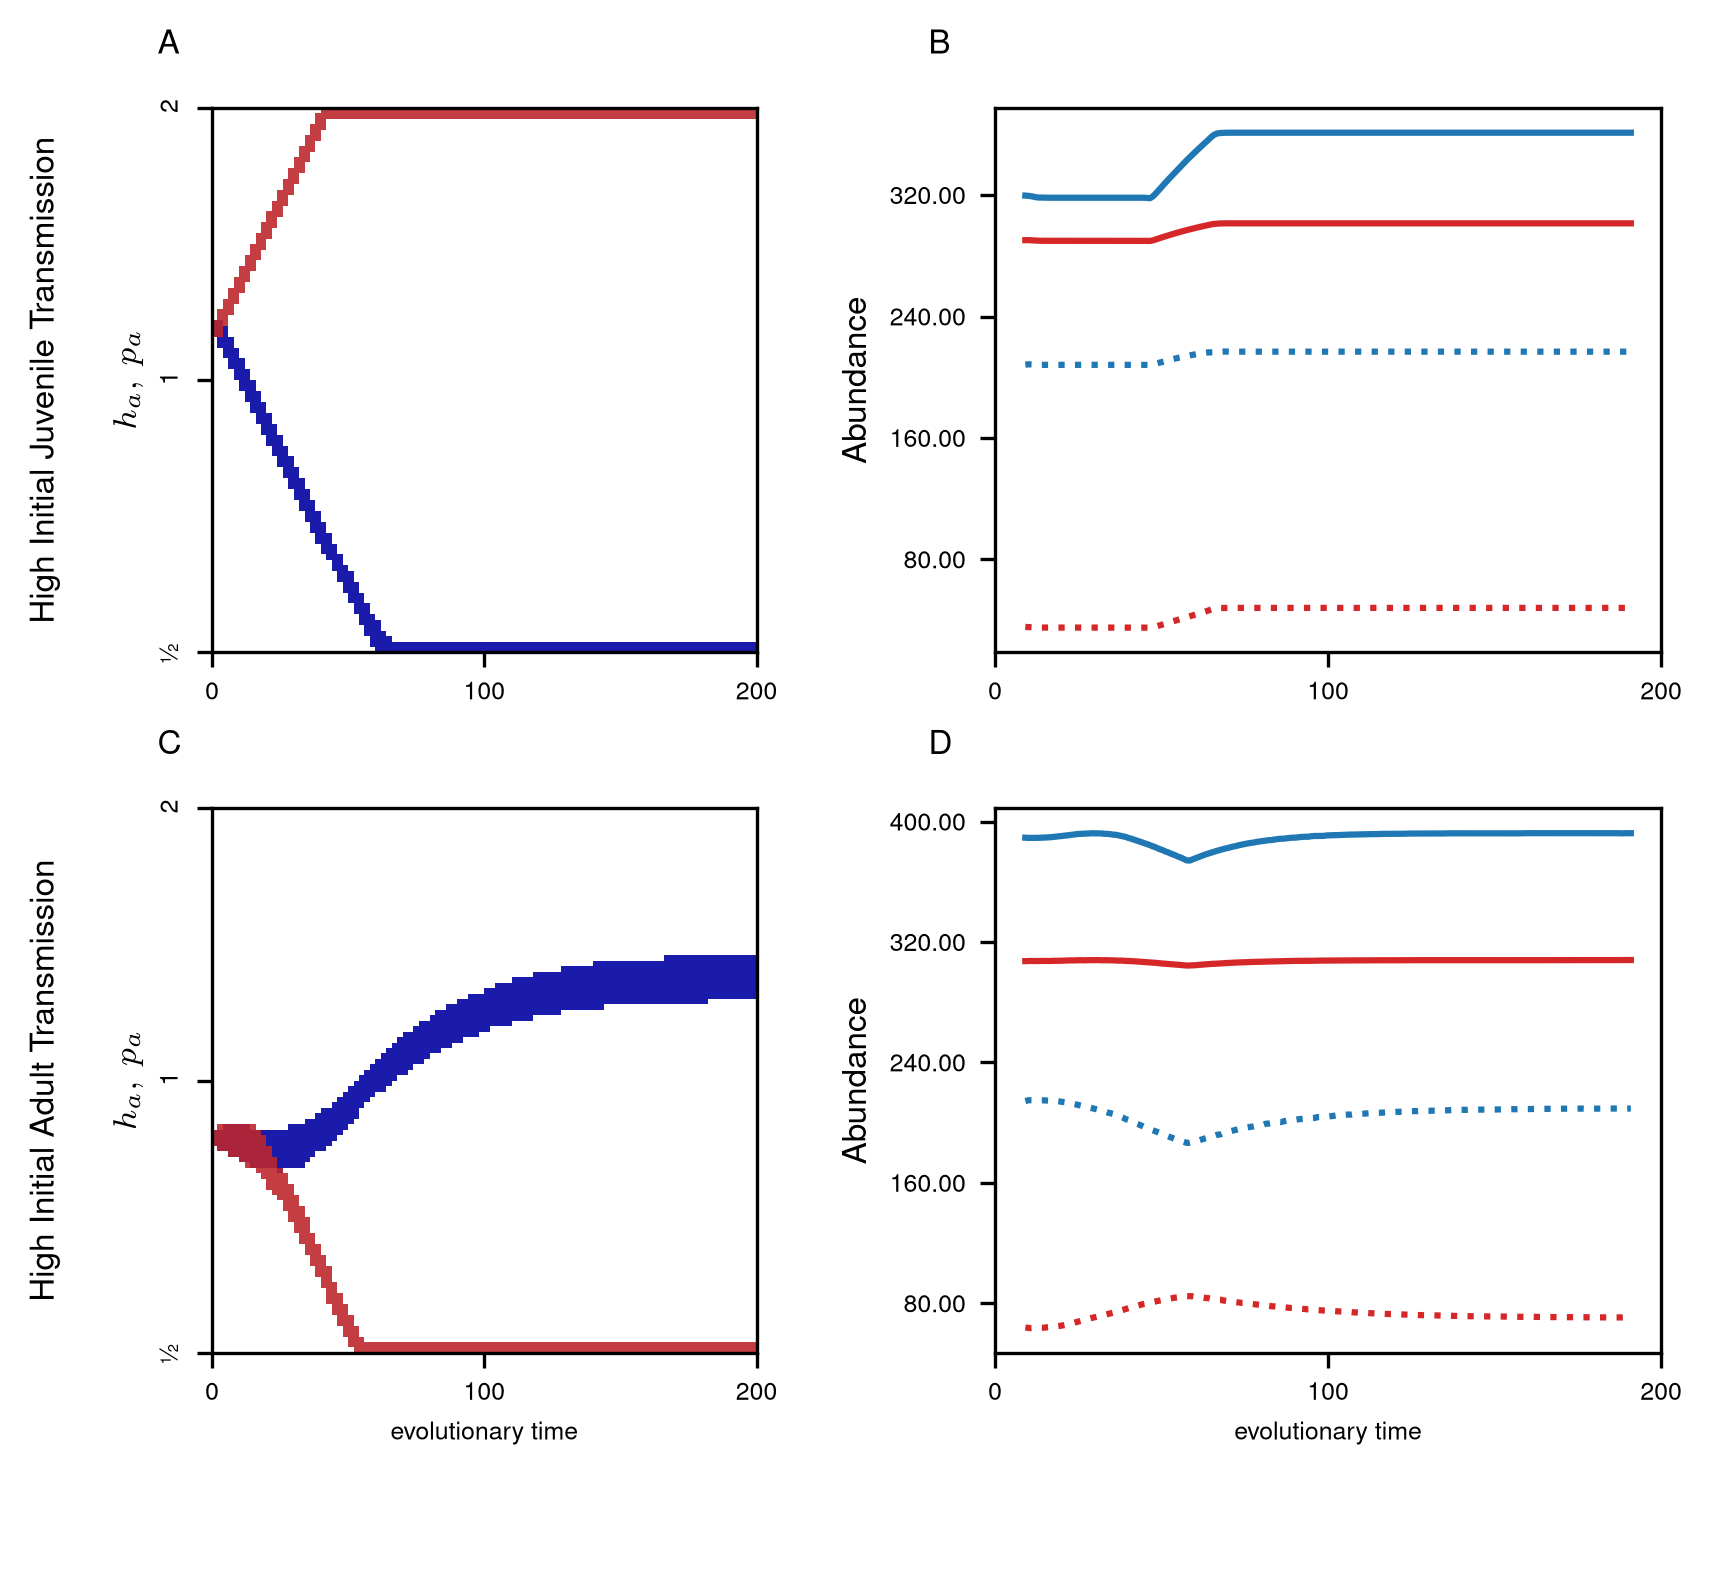

In [21]:
fig, ax = plt.subplots(ncols=2, nrows=2, layout='compressed')

cmap = matplotlib.colormaps['Blues']

Sa_img_1, Ia_img_1, Sa_alpha_1, Ia_alpha_1 = make_image(model_1.Sa, model_1.Ia)
Sa_img_2, Ia_img_2, Sa_alpha_2, Ia_alpha_2 = make_image(model_2.Sa, model_2.Ia)

ax[0,0].imshow(Sa_img_1, alpha=Sa_alpha_1, cmap=s_cmap)
ax[0,0].imshow(Ia_img_1, alpha=Ia_alpha_1, cmap=i_cmap)
ax[1,0].imshow(Sa_img_2, alpha=Sa_alpha_2, cmap=s_cmap)
ax[1,0].imshow(Ia_img_2, alpha=Ia_alpha_2, cmap=i_cmap)

ax[0,1].plot(np.sum(model_1.Sj, axis=0), color='tab:blue', linestyle=':')
ax[0,1].plot(np.sum(model_1.Sa, axis=0), color='tab:blue')
ax[0,1].plot(np.sum(model_1.Ij, axis=0), color='tab:red', linestyle=':')
ax[0,1].plot(np.sum(model_1.Ia, axis=0), color='tab:red')

ax[1,1].plot(np.sum(model_2.Sj, axis=0), color='tab:blue', linestyle=':', label=r'$S_j$')
ax[1,1].plot(np.sum(model_2.Sa, axis=0), color='tab:blue', label=r'$S_a$')
ax[1,1].plot(np.sum(model_2.Ij, axis=0), color='tab:red', linestyle=':', label=r'$I_j$')
ax[1,1].plot(np.sum(model_2.Ia, axis=0), color='tab:red', label=r'$I_a$')

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, model_1.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

for axis in ax[:,0]: 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)

    ax_tick_pos = np.linspace(axis.get_ylim()[0], axis.get_ylim()[1], 3)
    ax_tick_labels = [r'\sfrac{1}{2}',r'1',r'2']
    axis.set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)

    axis.set_ylabel(r'$h_a,\ p_a$', fontsize=8)

for axis in ax[:,1]: 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)

    axis.set_ylabel(r'Abundance', fontsize=8)

ax[1,0].set_xlabel(r'evolutionary time')
ax[1,1].set_xlabel(r'evolutionary time')

ax[0,0].annotate('High Initial Juvenile Transmission', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)
ax[1,0].annotate('High Initial Adult Transmission', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=8)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

lines, labels = ax[0,1].get_legend_handles_labels()
fig.legend(lines, labels, ncol=4, loc='center', bbox_to_anchor=(0.5, -0.05), frameon=False)